## Preparing the data and loading the model

In [1]:
import pandas as pd

fp = "./data/SMSSpamCollection.tsv"
df = pd.read_csv(fp, sep="\t", header=None, names=["label", "text"])
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [2]:
df['label'].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

In [ ]:
def create_balanced_subset(df):
    balanced_df = pd.DataFrame()
    vc = df['label'].value_counts()
    n_samples = vc.min()
    min_label = vc.idxmin()
    for label in df['label'].unique():
        if label == min_label:
            class_subset = df[df['label'] == label]
        else:
            class_subset = df[df['label'] == label].sample(n=n_samples, random_state=42)
        balanced_df = pd.concat([balanced_df, class_subset], ignore_index=True)

    return balanced_df

balanced_df = create_balanced_subset(df)
balanced_df['label'].value_counts()

label
ham     747
spam    747
Name: count, dtype: int64

In [5]:
balanced_df["label"] = balanced_df["label"].map({"ham": 0, "spam": 1})

In [12]:
def random_split(df, train_frac=0.7, valid_frac=0.1):
    df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(train_frac * n)
    val_end = train_end + int(valid_frac * n)

    train_df = df_shuffled[:train_end]
    val_df = df_shuffled[train_end:val_end]
    test_df = df_shuffled[val_end:]
    return train_df, val_df, test_df

train_df, val_df, test_df = random_split(balanced_df)

In [ ]:
train_df.to_csv("data/train.tsv", sep="\t", index=False)
val_df.to_csv("data/valid.tsv", sep="\t", index=False)
test_df.to_csv("data/test.tsv", sep="\t", index=False)

In [14]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})

[50256]

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


class SpamDataset(Dataset):
    def __init__(
        self, tokenizer, df=None, fp=None, max_length=None, pad_token_id=50256
    ):
        if df is None and fp is None:
            raise ValueError("Either df or fp must be provided.")
        if fp is not None:
            df = pd.read_csv(fp, sep="\t")
        self.texts = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.encoded_texts = [tokenizer.encode(text) for text in self.texts]
        self._set_max_length(max_length)
        self.encoded_texts = [
            ids + [pad_token_id] * (self.max_length - len(ids))
            for ids in self.encoded_texts
        ]

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        token_ids = self.encoded_texts[idx]
        label = self.labels[idx]
        return torch.tensor(token_ids), torch.tensor(label)

    def _set_max_length(self, max_length=None):
        max_ids_len = max(len(ids) for ids in self.encoded_texts)
        if max_length is not None:
            self.max_length = max_length
            if max_length < max_ids_len:
                self.encoded_texts = [ids[:max_length] for ids in self.encoded_texts]
        else:
            self.max_length = max_ids_len

In [17]:
train_dataset = SpamDataset(tokenizer, df=train_df)
print(f"Max sequence length in training set: {train_dataset.max_length}")
val_dataset = SpamDataset(tokenizer, df=val_df, max_length=train_dataset.max_length)
test_dataset = SpamDataset(tokenizer, df=test_df, max_length=train_dataset.max_length)

Max sequence length in training set: 109


In [21]:
num_workers = 0
batch_size = 8
torch.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, num_workers=num_workers, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, num_workers=num_workers, drop_last=False
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 130
Number of validation batches: 19
Number of test batches: 38


In [ ]:
# loading the model with pretrained weights

from gpt import GPTConfig, GPTModel
from utils import load_hf_gpt2_params, load_weights_into_gpt

hf_config, params = load_hf_gpt2_params()
gpt_cfg = GPTConfig.from_dict(hf_config.to_dict() | {"qkv_bias": True})
gpt_cfg.dropout = 0.0
model = GPTModel(gpt_cfg)
load_weights_into_gpt(model, params)
model.eval()

GPTModel(
  (token_embedding): Embedding(50257, 768)
  (pos_embedding): Embedding(1024, 768)
  (dropout): Dropout(p=0.0, inplace=False)
  (transformer_blocks): Sequential(
    (0-11): 12 x TransformerBlock(
      (attention): MultiHeadAttention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (ln1): LayerNorm()
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (final_layer_norm): LayerNorm()
  (out_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [32]:
from utils import text_to_tokens, tokens_to_text
from gpt import generate_text

token_ids = generate_text(
    model,
    text_to_tokens("Every effort moves you", tokenizer),
    max_length=15,
    context_length=gpt_cfg.context_length,
)
print(tokens_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [34]:
text = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text(
    model,
    text_to_tokens(text, tokenizer),
    max_length=20,
    context_length=gpt_cfg.context_length,
)
print(tokens_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You


## Add a classification head and fine-tune the model

In [35]:
for param in model.parameters():
    param.requires_grad = False

torch.manual_seed(42)
num_classes = 2
model.out_head = torch.nn.Linear(gpt_cfg.embedding_dim, num_classes)

for param in model.transformer_blocks[-1].parameters():
    param.requires_grad = True
for param in model.final_layer_norm.parameters():
    param.requires_grad = True

In [36]:
@torch.no_grad()
def calc_accuracy_dataloaders(model, dataloader,  num_batches=None):
    model.eval()
    if len(dataloader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))

    correct, total = 0, 0
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= num_batches:
            break
        device = next(model.parameters()).device
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)

        logits = model(input_batch)[:, -1, :]  # take the last token's logits
        predictions = torch.argmax(logits, dim=-1)
        correct += (predictions == target_batch).sum().item()
        total += target_batch.shape[0]

    return correct / total

In [39]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)

num_batches = 10
torch.manual_seed(42)
train_acc = calc_accuracy_dataloaders(model, train_loader, num_batches=num_batches)
val_acc = calc_accuracy_dataloaders(model, val_loader, num_batches=num_batches)
test_acc = calc_accuracy_dataloaders(model, test_loader, num_batches=num_batches)
print(f"Initial train accuracy: {train_acc * 100:.2f}%")
print(f"Initial validation accuracy: {val_acc * 100:.2f}%")
print(f"Initial test accuracy: {test_acc * 100:.2f}%")

Initial train accuracy: 50.00%
Initial validation accuracy: 53.75%
Initial test accuracy: 58.75%


In [40]:
def calc_loss_batch(
    input_batch: torch.Tensor, target_batch: torch.Tensor, model: GPTModel
) -> torch.Tensor:
    device = next(model.parameters()).device
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)[:, -1, :]
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

def calc_loss_dataloader(
    dataloader: DataLoader, model: GPTModel, num_batches: int | None = None
) -> float:
    total_loss = 0.0
    if len(dataloader) == 0:
        return float("nan")
    if num_batches is None:
        num_batches = len(dataloader)
    else:
        num_batches = min(num_batches, len(dataloader))
    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= num_batches:
            break
        loss = calc_loss_batch(input_batch, target_batch, model)
        total_loss += loss.item()
    average_loss = total_loss / num_batches
    return average_loss


In [43]:
num_batches = 5
with torch.no_grad():
    train_loss = calc_loss_dataloader(train_loader, model, num_batches=num_batches)
    val_loss = calc_loss_dataloader(val_loader, model, num_batches=num_batches)
    test_loss = calc_loss_dataloader(test_loader, model, num_batches=num_batches)
print(f"Initial training loss: {train_loss:.4f}")
print(f"Initial validation loss: {val_loss:.4f}")
print(f"Initial test loss: {test_loss:.4f}")

Initial training loss: 0.8868
Initial validation loss: 0.9217
Initial test loss: 0.7384


In [ ]:
def evaluate_model(
    model: GPTModel,
    train_dataloader: DataLoader,
    valid_dataloader: DataLoader,
    eval_iter: int,
) -> tuple[float, float]:
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_dataloader(
            train_dataloader, model, num_batches=eval_iter
        )
        valid_loss = calc_loss_dataloader(
            valid_dataloader, model, num_batches=eval_iter
        )
    model.train()
    return train_loss, valid_loss


def train_classifier(
    model: GPTModel,
    train_dataloader: DataLoader,
    valid_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    num_epochs: int,
    eval_freq: int,
    eval_iter: int,
) -> tuple[list[float], list[float], list[int], list[int], int]:
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []
    step, seen_count = 0, 0

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_dataloader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model)
            loss.backward()
            optimizer.step()
            step += 1
            seen_count += input_batch.shape[0]

            if step % eval_freq == 0:
                train_loss, valid_loss = evaluate_model(
                    model, train_dataloader, valid_dataloader, eval_iter
                )
                train_losses.append(train_loss)
                valid_losses.append(valid_loss)

                print(
                    f"Epoch {epoch + 1}/{num_epochs}, Step {step}, "
                    f"Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}"
                )

        with torch.no_grad():
            train_acc = calc_accuracy_dataloaders(
                model, train_dataloader, num_batches=eval_iter
            )
            val_acc = calc_accuracy_dataloaders(
                model, valid_dataloader, num_batches=eval_iter
            )
            train_accs.append(train_acc)
            valid_accs.append(val_acc)
        print(f"Train Accuracy: {train_acc * 100:.2f}%")
        print(f"Validation Accuracy: {val_acc * 100:.2f}%")

    return train_losses, valid_losses, train_accs, valid_accs, seen_count

In [ ]:
import time

torch.manual_seed(42)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs = 5

start = time.time()
train_losses, valid_losses, train_accs, valid_accs, samples_count = train_classifier(
    model,
    train_loader,
    val_loader,
    optimizer,
    num_epochs,
    eval_freq=50,
    eval_iter=5,
)
end = time.time()
print(f"Training took {end - start:.2f} seconds and saw {samples_count} samples.")

Epoch 1/5, Step 50, Train Loss: 0.6769, Valid Loss: 0.7234
Epoch 1/5, Step 100, Train Loss: 0.6543, Valid Loss: 0.6388
Train Accuracy: 92.50%
Validation Accuracy: 92.50%
Epoch 2/5, Step 150, Train Loss: 0.4644, Valid Loss: 0.4921
Epoch 2/5, Step 200, Train Loss: 0.1609, Valid Loss: 0.1760
Epoch 2/5, Step 250, Train Loss: 0.1293, Valid Loss: 0.1467
Train Accuracy: 90.00%
Validation Accuracy: 97.50%
Epoch 3/5, Step 300, Train Loss: 0.0747, Valid Loss: 0.1342
Epoch 3/5, Step 350, Train Loss: 0.1278, Valid Loss: 0.1227
Train Accuracy: 100.00%
Validation Accuracy: 97.50%
Epoch 4/5, Step 400, Train Loss: 0.0196, Valid Loss: 0.1395
Epoch 4/5, Step 450, Train Loss: 0.0141, Valid Loss: 0.1211
Epoch 4/5, Step 500, Train Loss: 0.0088, Valid Loss: 0.1372
Train Accuracy: 100.00%
Validation Accuracy: 97.50%
Epoch 5/5, Step 550, Train Loss: 0.0125, Valid Loss: 0.1208
Epoch 5/5, Step 600, Train Loss: 0.1186, Valid Loss: 0.1281
Epoch 5/5, Step 650, Train Loss: 0.1159, Valid Loss: 0.1379
Train Accuracy:

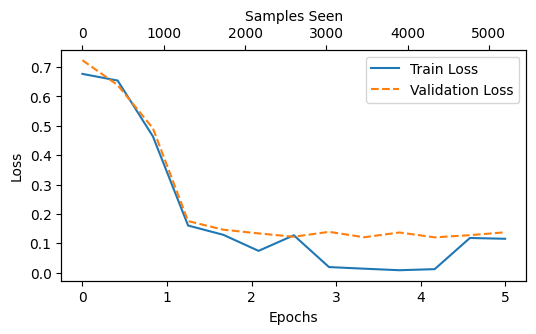

In [ ]:
import matplotlib.pyplot as plt

def plot(train_values, valid_values, epochs_num, samples_num, value_name="loss"):
    value_name = value_name.capitalize()
    _, ax1 = plt.subplots(figsize=(6, 3))
    ax1.plot(epochs_num, train_values, label=f"Train {value_name}")
    ax1.plot(epochs_num, valid_values, label=f"Validation {value_name}", linestyle='--')
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(value_name)
    ax1.legend()

    ax2 = ax1.twiny()
    ax2.plot(samples_num, train_values, alpha=0)
    ax2.set_xlabel("Samples Seen")
    plt.show()

epochs_num = torch.linspace(0, num_epochs, len(train_losses))
samples_num = torch.linspace(0, samples_count, len(train_losses))
plot(train_losses, valid_losses, epochs_num, samples_num)

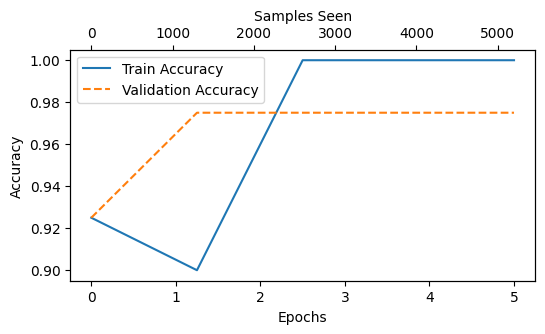

In [53]:
epochs_num = torch.linspace(0, num_epochs, len(train_accs))
samples_num = torch.linspace(0, samples_count, len(train_accs))
plot(train_accs, valid_accs, epochs_num, samples_num, value_name="accuracy")

In [56]:
train_acc = calc_accuracy_dataloaders(model, train_loader)
val_acc = calc_accuracy_dataloaders(model, val_loader)
test_acc = calc_accuracy_dataloaders(model, test_loader)
print(f"Train accuracy: {train_acc * 100:.2f}%")
print(f"Validation accuracy: {val_acc * 100:.2f}%")
print(f"Test accuracy: {test_acc * 100:.2f}%")

Train accuracy: 98.46%
Validation accuracy: 97.99%
Test accuracy: 96.33%


In [57]:
def predict_spam(text, model, tokenizer, max_length=None, pad_token_id=50256):
    model.eval()

    context_length = gpt_cfg.context_length
    if max_length is None:
        max_length = context_length
    max_length = min(max_length, context_length)
    token_ids = tokenizer.encode(text)[:max_length]
    token_ids += [pad_token_id] * (max_length - len(token_ids))

    device = next(model.parameters()).device
    input_tensor = torch.tensor(token_ids, device=device).unsqueeze(0)
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]
        prediction = torch.argmax(logits, dim=-1).item()

    return "spam" if prediction == 1 else "ham"


In [58]:
text = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)
predict_spam(text, model, tokenizer, max_length=train_dataset.max_length)

'spam'

In [ ]:
text_2 = (
    "How are you doing today? I hope you have a great day!"
)
predict_spam(text_2, model, tokenizer, max_length=train_dataset.max_length)

'ham'

In [61]:
from utils import save_checkpoint

save_checkpoint(model=model, optimizer=None, filepath="spam_classifier.pth")